# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/T0othIess/FlyRank-AI-ML-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**The research question:** of the published pages that have Google Search Console data available, which pages have lower click-through rate (CTR) than their expected CTR for the comparable positions, and which pages should be prioritized for review?  

**The decision it supports:** it supports an SEO's team decision about which page needs to be reviewed first for improvements such as title, search-intent,etc..  
it produces a ranked queue rather than saying a change in some feature will guarantee an improvement in CTR.

In [15]:
import os
from huggingface_hub import login
import duckdb

HF_TOKEN = os.environ.get("HF_TOKEN")
login(HF_TOKEN)
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
rel = "hf://datasets/FlyRank/internship-warehouse"
con.sql(f"DESCRIBE SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')").show()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


┌────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │ column_type │  null   │   key   │ default │  extra  │
│      varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ report_date        │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ client_hash_id     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ content_hash_id    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_gsc     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ client_has_ga4     │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ ga4_data_available │ BOOLEAN     │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_impressions    │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ gsc_clicks         │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release used:**  
The capstone uses the FlyRank AI/ML internship warehouse on Hugging Face.

**Tables used:**

- `fact_content_daily_performance`: daily search-performance data at the `report_date x client_hash_id x content_hash_id` grain.
- `dim_content`: content-level search context such as `search_volume`, `competition_level`, and `main_intent`.

The two tables are joined using `content_hash_id`.

**Date window:**  
The development window is March 2026 (`month=2026-03`). June 2026 is the sealed final month in the warehouse, so it is not used to create or tune the model rules.

`fact_content_query_90d` is not used because its 90-day window reaches into June, which would mix the sealed month into the development work.

**Excluded and why:**

- Rows without GSC data, deleted content, non-positive search position, or missing `search_volume` / `competition_level` are removed because the fields needed for this analysis are not available.
- Pages with fewer than 200 total March impressions are removed because the earlier baseline showed that very low-impression pages add a lot of noise.
- `gsc_clicks` and `gsc_impressions` are not model features because they are used to calculate CTR and the CTR gap.
- GA4/session/scroll fields and AI-referral fields are not model features because this project is specifically about Google Search CTR; mixing post-visit behavior or other traffic channels into the predictor would make the result harder to interpret.
- Client names, domains, raw URLs, and private queries are not included in public outputs.


In [16]:
import pandas as pd

fact_content_daily_performance_table = con.sql(f"SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/*.parquet')")
dim_content_table  = con.sql(f"SELECT * from read_parquet('{rel}/dim_content.parquet')")

print("fact_content_daily_performance_table grain: ")
con.sql("""SELECT report_date , client_hash_id, content_hash_id, COUNT(*) AS n FROM fact_content_daily_performance_table
            GROUP BY report_date , client_hash_id, content_hash_id HAVING COUNT(*) > 1""").show()

print("dim_content_table grain: ")
con.sql("SELECT content_hash_id, COUNT(*) AS n FROM dim_content_table GROUP BY content_hash_id HAVING COUNT(*) > 1").show()

print("Available data: ")
#concat combines strings, first string would be the number (39.69) + '%'
con.sql("""SELECT MIN(report_date) AS earliest_date, MAX(report_date) AS latest_date, COUNT(*) AS total_rows, COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS available_rows,
           CONCAT(ROUND(100 * COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) / COUNT(*), 2), '%') AS pct_available from fact_content_daily_performance_table""").show()


fact_content_daily_performance_table grain: 
┌─────────────┬────────────────┬─────────────────┬───────┐
│ report_date │ client_hash_id │ content_hash_id │   n   │
│    date     │    varchar     │     varchar     │ int64 │
└─────────────┴────────────────┴─────────────────┴───────┘
                          0 rows                        

dim_content_table grain: 
┌─────────────────┬───────┐
│ content_hash_id │   n   │
│     varchar     │ int64 │
└─────────────────┴───────┘
          0 rows         

Available data: 
┌───────────────┬─────────────┬────────────┬────────────────┬───────────────┐
│ earliest_date │ latest_date │ total_rows │ available_rows │ pct_available │
│     date      │    date     │   int64    │     int64      │    varchar    │
├───────────────┼─────────────┼────────────┼────────────────┼───────────────┤
│ 2026-03-01    │ 2026-03-31  │    9841378 │        3611061 │ 36.69%        │
└───────────────┴─────────────┴────────────┴────────────────┴───────────────┘



## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions:**

- CTR is affected by search position: pages in better positions should, on average, get higher CTR.
- Pages with very low impressions are noisy, so pages with fewer than 200 total impressions across March are filtered out before modeling.
- Pages with much lower CTR than the expected CTR for their position tier are candidates for review.
- Each row represents one `(client_hash_id x content_hash_id)` pair aggregated across the entire month of March 2026.

**Features:**

- `weighted_avg_position`
- one-hot encoded `position_tier`
- `log_search_volume`
- encoded `competition_level`

The position tiers are:

- `page_1`: position 0-10
- `striking`: position 10-20
- `page_3_plus`: position above 20

**Label definition:**

`ctr_gap` is calculated as the expected CTR for a page's position tier minus its observed CTR. Larger positive values mean the page is receiving fewer clicks than expected for its tier.

The original label used one flat `ctr_gap >= 0.002` threshold across all tiers. That was a problem because the tiers have different expected CTR values. In the old version, pages in the lowest-position tier could not reach the flat threshold at all.

The corrected version makes two changes:

1. Expected CTR is calculated from **training rows only** for each position tier.
2. Each tier gets its own high-gap threshold: the 70th percentile of training `ctr_gap` values inside that tier.

A page is labeled `is_high_gap = 1` when its `ctr_gap` is greater than or equal to the training threshold for its own tier.

In the diagnostic training split, the `page_3_plus` tier ends up with more than the intended ~30% flagged because many zero-click pages tie exactly at the percentile boundary. Since the rule uses `>=`, the full tie is included. This is kept as a limitation rather than adding a more complicated tie-breaking rule.

**Baseline:**

- Rank the test pages by `ctr_gap` from largest to smallest.
- Treat the top of that ranking as the baseline review queue.

This is intentionally a very strong, label-informed baseline because `ctr_gap` is also part of the label definition. It is used as a reference point, not as a realistic pre-click model.

**Validation design:**

The evaluation is grouped by client rather than splitting individual pages randomly.

- `GroupShuffleSplit` uses `client_hash_id` as the group.
- All pages from one client stay entirely in train or entirely in test.
- Because clients have very different numbers of pages, 20% of the client groups does not always mean 20% of the rows.
- The final validation uses 50 grouped splits without filtering them by row count.
- Final performance is reported using mean Precision@k across the 50 splits, with the minimum and maximum shown to make the instability visible.

**Leakage checks:**

- `total_clicks`, `total_impressions`, `ctr`, `expected_ctr`, `ctr_gap`, `gap_threshold`, and `is_high_gap` are not model features.
- Expected CTR is rebuilt from training rows only for every final split.
- The tier-specific 70th-percentile thresholds are also rebuilt from training rows only.
- The same client cannot appear in both train and test.
- Post-visit and other-channel metrics are not used as model features.


In [17]:

#time for some explanation:
#first of all: we grouped by client id and content id without report date BECAUSE the old dataframe was counting for each page each day, meaning multiple rows could have the same page
#but just on different days, that created noise at the end of ranking because at the top there could be the same page repeated just on different days
#the way to solve it is to group by client and content alone, which means for each page on a certain client we get the data that happened across the ENTIRE month, not just per day

#which brings us to a 2nd explanation about why we used sum() on each column
#the reason is because we used group by, in SQL, columns have 2 options when we are using group by:
#1- be included in the group by clause (like client id and content id)
#2- get aggregated with SUM, AVG, ANY_VALUE, and what not
#if u leave it as is like doing f.gsc_avg_position as a column, it would give an error
#thats why for some columns that have the same value for all rows across the days (like d.main_intent for example), we used ANY_VALUE
#because it satisfies the condition for columns when using GROUP BY, its just used for columns that have the same value across the rows

#AS FOR THE EQUATION ON AVG_POSITION:
#one of the issues we had is that avg_position gets played a lot on low impressions, basically impressions matter a lot
#thats why we have to do a weighted avg, not a normal average, where the weight in the equation is impressions.
#if u dont understand u can look up what the formula for weighted average is
df = con.sql("""SELECT f.client_hash_id, f.content_hash_id, SUM(f.gsc_clicks) AS total_clicks, SUM(f.gsc_impressions) AS total_impressions,
                SUM(f.gsc_avg_position * f.gsc_impressions) *1.0 / SUM(f.gsc_impressions) AS weighted_avg_position,
                ANY_VALUE(d.search_volume) AS search_volume, ANY_VALUE(d.competition_level) AS competition_level, ANY_VALUE(d.main_intent) AS main_intent
                FROM fact_content_daily_performance_table AS f JOIN dim_content_table AS d USING(content_hash_id)
                WHERE
                    f.gsc_data_available IS TRUE AND d.is_deleted IS FALSE AND f.gsc_avg_position >0 AND d.search_volume IS NOT NULL AND d.competition_level IS NOT NULL
                GROUP BY f.client_hash_id, f.content_hash_id ORDER BY f.client_hash_id, f.content_hash_id""").df()

print(f"shape: {df.shape}")

shape: (159054, 8)


In [18]:
import numpy as np
# GroupShuffleSplit works like train_test_split, but takes a "groups" argument
# that keeps all rows belonging to the same group (here, same client) on the
# same side of the split - either all in train, or all in test, never both.
# n_splits=1 means we only want ONE version of this split (not multiple, which
# GroupShuffleSplit also supports for things like cross-validation).
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OneHotEncoder
test = df["total_impressions"]
print(f"Min: {test.min()}")
print(f"Median: {test.median()}")
print(f"Mean: {test.mean()}")
print(f"Max: {test.max()}\n")

#percentile explained:
#the value stored on the left is the value used in the percentile
#percentile rule example: 50th of impressions have <= X
#the numpy percentile function finds us the X and we store it in p50 for example
p50 = np.percentile(test, 50)
p70 = np.percentile(test, 70)
p90 = np.percentile(test, 90)
p95 = np.percentile(test, 95)
p99 = np.percentile(test, 99)

print(f"50th: {p50}")
print(f"70th: {p70}")
print(f"90th: {p90}")
print(f"95th: {p95}")
print(f"99th: {p99}")

thresholds = [10,50,100,150,200,300,500,1000]

for threshold in thresholds:
    #to explain the logic rq, (df["total_impressions"] >= threshold) returns a series wtih true and falses, sum calculates only the true's (since they are 1 in binary) to give the count
    print(f"Amount of pages at {threshold}-> {(df["total_impressions"] >= threshold).sum()}")

#the whole point of what was above is to help me determine a minimum impressions limit to help me remove noise that happened in w04 where the top 10 all had like 1-10 impressions
df = df.query("total_impressions >= 200").reset_index(drop=True)
df["main_intent"] = df["main_intent"].astype("category")

competition_ranks = pd.api.types.CategoricalDtype(categories=["LOW", "MEDIUM", "HIGH"], ordered=True)
df["competition_level"] = df["competition_level"].astype(competition_ranks)
df["position_tier"] = pd.cut(df["weighted_avg_position"], bins=[0,10,20,float("inf")], labels=["page_1", "striking", "page_3_plus"])

df["ctr"] = df["total_clicks"] / df["total_impressions"]

competition_map = {"LOW": 0, "MEDIUM": 1, "HIGH":2}
df["competition_level_enc"] = df["competition_level"].map(competition_map)

#creates the one-hot encoder object
#the reason for sparse_output=False is so that the position_encoded has type numpy.ndarry which works with DataFrame, cuz without it it would be a sprase smthn type,
#which doesnt work and raises an error.
ohe = OneHotEncoder(sparse_output=False)
categories = ["position_tier"]
#position_tier already comes from fixed bins, so the encoder is only turning those fixed categories into 1s and 0s
position_encoded = ohe.fit_transform(df[categories])

#get the column names, reason why it was on ohe not position_encoded because position_encoded is a matrix without column names, ohe creates the column names
position_columns = ohe.get_feature_names_out(categories)

#the reason for index= df.index is to ensure the dataframe doesnt mix up cuz it will be added to df, so it must have it's index
position_df = pd.DataFrame(data=position_encoded, columns=position_columns, index=df.index)
df[position_columns] = position_df

#basically because search_volume is heavily skewed, we use log for it so that the model doesnt depend too much on it basically
#log1p(x) means log(1+x), reason for the 1+ is cuz x can be 0, to not get a math error
df["log_search_volume"] = np.log1p(df["search_volume"])

feature_list = ["weighted_avg_position", "log_search_volume", "competition_level_enc"] + position_columns.tolist()
X = df[feature_list]


#this next seed search was an early experiment to get one easy-to-read grouped split close to 80/20 by ROW count
#the final validation later does NOT filter seeds this way, because GroupShuffleSplit is splitting client groups, not rows

groups = df["client_hash_id"]
seeds_data = {"seed": [], "train_split": [], "test_split": []}
best_seed = None
best_diff = float("inf")
best_fraction = None
for seed in range(1, 301):
    gss_try = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    # Step 2 (gss = GroupShuffleSplit(...)) only set up the RULES (80/20 ratio, seed, how many splits). It didn't touch our actual data at all.
    # .split(X, y, groups=groups) is the step that actually DOES the splitting.
    # this is where our real data finally gets divided according to those rules.
    # The only quirk: because GroupShuffleSplit can generate multiple different splits (for cross-validation), .split() hands back a generator instead of
    # a plain answer, it produces splits one at a time, on request.
    # Since we only want 1 split, next() grabs that single result.
    train_idx_try, test_idx_try = next(gss_try.split(X, groups=groups))
    fraction_try = len(test_idx_try) / len(X)
    diff = abs(fraction_try - 0.2)
    if diff < 0.01:
        seeds_data["seed"].append(seed)
        seeds_data["train_split"].append(f"{len(train_idx_try) / len(X):%}")
        seeds_data["test_split"].append(f"{fraction_try:%}")
        
    if diff < best_diff:
        best_diff = diff
        best_seed = seed
        best_fraction = fraction_try

gss = GroupShuffleSplit(test_size =0.2, n_splits = 1, random_state = best_seed)


train_idx, test_idx = next(gss.split(X, groups= groups))

train_clients = set(df.iloc[train_idx]["client_hash_id"])
test_clients = set(df.iloc[test_idx]["client_hash_id"])

print(f"Clients shared by train and test(grouped model): {len(train_clients & test_clients)}")

X_E_train = X.iloc[train_idx]
X_E_test = X.iloc[test_idx]

expected_ctr_per_tier = df.loc[X_E_train.index].groupby("position_tier")["total_clicks"].sum() / df.loc[X_E_train.index].groupby("position_tier")["total_impressions"].sum()
df["expected_ctr"] = df["position_tier"].map(expected_ctr_per_tier).astype(float)
df["ctr_gap"] = df["expected_ctr"] - df["ctr"]

#to determine the threshold that will define is_high_gap label
test = df["ctr_gap"]
print("\nctr_gap threshold calculations: ")
print(f"Min: {test.min()}")
print(f"Median: {test.median()}")
print(f"Mean: {test.mean()}")
print(f"Max: {test.max()}\n")

p50 = np.percentile(test, 50)
p70 = np.percentile(test, 70)
p90 = np.percentile(test, 90)
p95 = np.percentile(test, 95)
p99 = np.percentile(test, 99)

print(f"50th: {p50}")
print(f"70th: {p70}")
print(f"90th: {p90}")
print(f"95th: {p95}")
print(f"99th: {p99}")


Min: 1.0
Median: 227.0
Mean: 1746.8509751405184
Max: 617124.0

50th: 227.0
70th: 870.0
90th: 4385.0
95th: 7878.0
99th: 23049.99000000002
Amount of pages at 10-> 135873
Amount of pages at 50-> 111409
Amount of pages at 100-> 97940
Amount of pages at 150-> 89200
Amount of pages at 200-> 82507
Amount of pages at 300-> 73065
Amount of pages at 500-> 60934
Amount of pages at 1000-> 44602
Clients shared by train and test(grouped model): 0

ctr_gap threshold calculations: 
Min: -0.07559942181579059
Median: 0.001369257363851267
Mean: 0.0004708774553298521
Max: 0.0037109230117956292

50th: 0.001369257363851267
70th: 0.0023933999551421377
90th: 0.0037109230117956292
95th: 0.0037109230117956292
99th: 0.0037109230117956292


There was a real issue with the original `is_high_gap` label from the earlier modeling notebook.

The old version used one flat threshold (`ctr_gap >= 0.002`) for every position tier. But the expected CTR is different for every tier. In the old `page_3_plus` group, the expected CTR itself was below `0.002`, so even a page with zero clicks could not reach the flat threshold. That made the label strongly tied to the position tier instead of fairly comparing pages within similar positions.

The earlier version also calculated expected CTR before the train/test split, so test outcomes influenced the quantity used to build the test label.

The correction is simple:

- calculate expected CTR from training rows only;
- calculate a separate 70th-percentile `ctr_gap` threshold for each position tier using training rows only.

This fixes the impossible flat-threshold problem and removes test data from the expected-CTR/threshold calculations.


In [19]:
train_df = df.iloc[train_idx]

#returns a series of the 70th percentile for each position tier
gap_threshold_per_tier = train_df.groupby("position_tier")["ctr_gap"].quantile(0.70)
display(gap_threshold_per_tier.to_frame("Gap Threshold Per Tier").reset_index().style.hide(axis="index"))

df["gap_threshold"] = df["position_tier"].map(gap_threshold_per_tier).astype(float)
df["is_high_gap"] = (df["ctr_gap"] >= df["gap_threshold"]).astype(int)

#making train_df again because is_high_gap was just added to df
train_df = df.iloc[train_idx]

display(train_df.groupby("position_tier")["is_high_gap"].mean().to_frame("Position Tier Flagged Pages Mean").reset_index().style.hide(axis="index"))
display(train_df.query("position_tier == 'page_3_plus'")["ctr_gap"].value_counts().head().to_frame("Pages with certain gaps").reset_index().style.hide(axis="index"))


position_tier,Gap Threshold Per Tier
page_1,0.002649
striking,0.003290
page_3_plus,0.001369


position_tier,Position Tier Flagged Pages Mean
page_1,0.300016
striking,0.330176
page_3_plus,0.443050


ctr_gap,Pages with certain gaps
0.001369,6990
-0.002267,14
-0.002615,12
-0.003095,10
-0.003606,10


On the diagnostic training split, `page_1` lands almost exactly at the intended 30%. `striking` is about 33%, and `page_3_plus` is about 44%.

The `page_3_plus` overshoot comes from a large tie at the percentile boundary: many zero-click pages have the exact same `ctr_gap`. Because the rule uses `>=`, all pages tied at that boundary are included.

I am not adding a complicated tie-breaking rule for this capstone. The label is a practical heuristic for review prioritization, so this behavior is kept and clearly listed as a limitation.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The first code cell below is a simple single-split check and also compares the full model with a version that removes the one-hot `position_tier` columns.

The **final result**, however, comes from the 50 repeated client-grouped holdouts under **Final validation approach**. For every one of those splits, expected CTR, the tier thresholds, the labels, and the logistic regression model are rebuilt from that split's training data.

The final model is compared with:

- random selection, represented by the positive rate in that test split;
- the strong `ctr_gap` baseline on the same test rows;
- the logistic regression ranking.

The model never uses clicks, impressions, CTR, expected CTR, CTR gap, or the label as features.


In [20]:
from sklearn.linear_model import LogisticRegression

y = df["is_high_gap"]
y_E_train = y.iloc[train_idx]
y_E_test = y.iloc[test_idx]

#initialziing the model
#logistic regression learns by iteration, and setting the max to 1000 is common
model_E = LogisticRegression(max_iter=1000, random_state=1)

#training the model
model_E.fit(X_E_train, y_E_train)

#model.predict_proba(X_test) returns an array of shape (n_test_samples, 2) where column 0 is probability of class 0 (is_high_gap = 0)
#and column 1 is probability of class 1 (is_high_gap = 1)
#to explain [:,1], in numpy : means get all rows, 1 means column 1 of the rows
#so basically it gets me a 1d array of the column 1 values for all the rows
y_E_pred_proba = model_E.predict_proba(X_E_test)[:,1]

#df.loc[rows, columns] thats the syntax
test_df_E = df.loc[X_E_test.index].copy()
test_df_E["is_high_gap"] = y_E_test.values
test_df_E["predicted_high_gap"] = y_E_pred_proba
test_df_model_E = test_df_E.sort_values("predicted_high_gap", ascending=False)

X_F = X.drop(columns=position_columns.tolist())
print(X_F.columns)
y_F = y

X_F_train = X_F.iloc[train_idx]
X_F_test = X_F.iloc[test_idx]
y_F_train = y_E_train
y_F_test = y_E_test

model_F = LogisticRegression(max_iter=1000, random_state=1)
model_F.fit(X_F_train, y_F_train)
y_F_pred_proba = model_F.predict_proba(X_F_test)[:,1]

test_df_F = df.loc[X_F_test.index].copy()
test_df_F["is_high_gap"] = y_F_test.values
test_df_F["predicted_high_gap"] = y_F_pred_proba
test_df_model_F = test_df_F.sort_values("predicted_high_gap", ascending=False)

test_df_baseline = test_df_E.sort_values("ctr_gap", ascending=False)

data = {"k": [], "Baseline Precision@k": [], "Model E Precision@k": [], "Model F(no position_tier) Precision@k": []}
for k in [20,50,100,200,500,1000]:
    data["k"].append(k)
    top_k_baseline = test_df_baseline.head(k)
    baseline_precision_at_k = top_k_baseline["is_high_gap"].sum() / k
    data["Baseline Precision@k"].append(baseline_precision_at_k)

    top_k_model_E = test_df_model_E.head(k)
    model_E_precision_at_k = top_k_model_E["is_high_gap"].sum() / k
    data["Model E Precision@k"].append(model_E_precision_at_k)

    top_k_model_F = test_df_model_F.head(k)
    model_F_precision_at_k = top_k_model_F["is_high_gap"].sum() / k
    data["Model F(no position_tier) Precision@k"].append(model_F_precision_at_k)



#note: results isnt a dataframe, its a styler object, because we used .style
display(pd.DataFrame(data).style.hide(axis="index")
        .format("{:.1%}", subset=["Baseline Precision@k", "Model E Precision@k", "Model F(no position_tier) Precision@k"]).set_properties(**{"text-align": "center"}))

display(pd.Series(model_E.coef_[0], index=feature_list).sort_values().to_frame(name="Coefficients"))


Index(['weighted_avg_position', 'log_search_volume', 'competition_level_enc'], dtype='str')


k,Baseline Precision@k,Model E Precision@k,Model F(no position_tier) Precision@k
20,100.0%,95.0%,95.0%
50,100.0%,94.0%,96.0%
100,100.0%,94.0%,94.0%
200,100.0%,91.5%,89.0%
500,100.0%,83.4%,83.4%
1000,100.0%,74.5%,75.8%


,Coefficients
position_tier_page_3_plus,-0.845375
position_tier_striking,-0.366781
position_tier_page_1,-0.060058
competition_level_enc,-0.017656
weighted_avg_position,0.051116
log_search_volume,0.094311


### Final validation approach

Because client sizes are highly uneven, relying on one grouped train/test split can give a misleading result depending on which clients happen to land in the test set.

At first, I tried to solve this by only keeping the seeds that gave a test set close to 20% of the total rows. However, `GroupShuffleSplit(test_size=0.2)` is splitting around 20% of the **client groups**, not 20% of the rows. Since some clients have way more pages than others, a valid grouped split can naturally have way more or less than 20% of the rows in test. Filtering for only the seeds close to an 80/20 row split could therefore remove splits where one of the larger clients happened to land in test.

Because of that, the final validation will no longer only use the seeds stored in `seeds_data["seed"]`. Instead, I will evaluate the model using 50 different grouped splits. For every seed, the expected CTR, tier-specific gap thresholds, labels, and model are rebuilt using that seed's training data before evaluating on its unseen clients.

For every `k`, the model will be compared against the `ctr_gap` baseline and random guessing. The final evaluation will use the mean Precision@k across all seeds, while also reporting the minimum and maximum to show how much the result changes depending on which clients land in the test set.

The same evaluations will also be used later for the ranked queue. Whenever a page appears in the test set, its prediction and label-related values are saved. If the same page appears in test across multiple seeds, those values can then be averaged so the final queue is only using results from times where that page's client was unseen by the model.


In [21]:
ks = [20,50,100,200,500,1000]

#final_data will store everything we need for the first table, where every row will be one seed
final_data = {"seed": [], "train_split": [], "test_split": [], "largest_client_share": []}

for k in ks:
    final_data[f"random_at_{k}"] = []
    final_data[f"baseline_at_{k}"] = []
    final_data[f"model_at_{k}"] = []

#this will store the pages that appeared in test for every seed
#later on we can put them all together and get the mean for pages that appeared more than once
queue_data = []

#we dont use seeds_data["seed"] here anymore because those seeds were picked based on getting close to 80/20 by ROW count
#GroupShuffleSplit is splitting the clients though, so because clients have very different amounts of pages, the row split doesnt have to be close to 80/20
for seed in range(1,51):

    gss_seed = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_seed_idx, test_seed_idx = next(gss_seed.split(X, groups=groups))

    final_data["seed"].append(seed)
    final_data["train_split"].append(len(train_seed_idx) / len(X))
    final_data["test_split"].append(len(test_seed_idx) / len(X))

    #copying df because expected_ctr, ctr_gap and the label will be different for every seed
    #this way one seed doesnt change the dataframe used by the seed after it
    df_seed = df.copy()

    train_df_seed = df_seed.iloc[train_seed_idx]
    test_df_seed = df_seed.iloc[test_seed_idx].copy()

    train_clients_seed = set(train_df_seed["client_hash_id"])
    test_clients_seed = set(test_df_seed["client_hash_id"])

    #if this assert fails then the same client leaked into train and test
    assert len(train_clients_seed & test_clients_seed) == 0, "A client leaked between train and test"

    #this only shows us how unbalanced the test set is, it is not used to remove any seeds
    largest_client_share_seed = test_df_seed["client_hash_id"].value_counts(normalize=True).iloc[0]
    final_data["largest_client_share"].append(largest_client_share_seed)

    #expected_ctr has to be calculated again for every seed using only that seed's training rows
    expected_ctr_seed = train_df_seed.groupby("position_tier")["total_clicks"].sum() / train_df_seed.groupby("position_tier")["total_impressions"].sum()

    df_seed["expected_ctr"] = df_seed["position_tier"].map(expected_ctr_seed).astype(float)
    df_seed["ctr_gap"] = df_seed["expected_ctr"] - df_seed["ctr"]

    #making train_df_seed again because ctr_gap was just added
    train_df_seed = df_seed.iloc[train_seed_idx]

    #same idea for the threshold, it is learned only from training rows
    gap_threshold_seed = train_df_seed.groupby("position_tier")["ctr_gap"].quantile(0.70)

    df_seed["gap_threshold"] = df_seed["position_tier"].map(gap_threshold_seed).astype(float)
    df_seed["is_high_gap"] = (df_seed["ctr_gap"] >= df_seed["gap_threshold"]).astype(int)

    X_train_seed = X.iloc[train_seed_idx]
    X_test_seed = X.iloc[test_seed_idx]

    y_seed = df_seed["is_high_gap"]
    y_train_seed = y_seed.iloc[train_seed_idx]
    y_test_seed = y_seed.iloc[test_seed_idx]

    model_seed = LogisticRegression(max_iter=1000, random_state=1)
    model_seed.fit(X_train_seed, y_train_seed)

    predicted_seed = model_seed.predict_proba(X_test_seed)[:,1]

    #making test_df_seed again because the label columns were added after the first copy
    test_df_seed = df_seed.iloc[test_seed_idx].copy()
    test_df_seed["predicted_high_gap"] = predicted_seed

    model_ranking_seed = test_df_seed.sort_values("predicted_high_gap", ascending=False)
    baseline_ranking_seed = test_df_seed.sort_values("ctr_gap", ascending=False)

    #random guessing precision is just the percentage of high-gap pages in this seed's test set
    random_precision_seed = y_test_seed.mean()

    for k in ks:
        model_precision_seed = model_ranking_seed.head(k)["is_high_gap"].mean()
        baseline_precision_seed = baseline_ranking_seed.head(k)["is_high_gap"].mean()

        final_data[f"random_at_{k}"].append(random_precision_seed)
        final_data[f"baseline_at_{k}"].append(baseline_precision_seed)
        final_data[f"model_at_{k}"].append(model_precision_seed)

    #only TEST rows are saved, so these predictions came from a model that did not train on that page's client
    queue_seed = test_df_seed[["client_hash_id", "content_hash_id", "predicted_high_gap", "expected_ctr", "ctr_gap", "is_high_gap"]].copy()
    queue_seed["seed"] = seed

    queue_data.append(queue_seed)


final_df = pd.DataFrame(final_data)

percent_columns = ["train_split", "test_split", "largest_client_share"]

for k in ks:
    percent_columns += [f"random_at_{k}", f"baseline_at_{k}", f"model_at_{k}"]

#showing only the main split diagnostics here so the notebook does not print a massive 22-column table
split_display_columns = ["seed", "train_split", "test_split", "largest_client_share",
                         "random_at_20", "baseline_at_20", "model_at_20"]

display(final_df[split_display_columns].style.hide(axis="index").format(
    "{:.2%}",
    subset=[c for c in split_display_columns if c != "seed"]
))


#now we take the results from all the seeds and summarize them for every k
summary_data = {"k": [], "random_mean": [], "random_min": [], "random_max": [],
                "baseline_mean": [], "baseline_min": [], "baseline_max": [],
                "model_mean": [], "model_min": [], "model_max": []}

for k in ks:

    summary_data["k"].append(k)

    summary_data["random_mean"].append(final_df[f"random_at_{k}"].mean())
    summary_data["random_min"].append(final_df[f"random_at_{k}"].min())
    summary_data["random_max"].append(final_df[f"random_at_{k}"].max())

    summary_data["baseline_mean"].append(final_df[f"baseline_at_{k}"].mean())
    summary_data["baseline_min"].append(final_df[f"baseline_at_{k}"].min())
    summary_data["baseline_max"].append(final_df[f"baseline_at_{k}"].max())

    summary_data["model_mean"].append(final_df[f"model_at_{k}"].mean())
    summary_data["model_min"].append(final_df[f"model_at_{k}"].min())
    summary_data["model_max"].append(final_df[f"model_at_{k}"].max())

summary_df = pd.DataFrame(summary_data)

summary_percent_columns = ["random_mean", "random_min", "random_max",
                           "baseline_mean", "baseline_min", "baseline_max",
                           "model_mean", "model_min", "model_max"]

display(summary_df.style.hide(axis="index").format("{:.2%}", subset=summary_percent_columns))


#queue_data is a list of the test rows saved from every seed
#concat stacks them into one dataframe
all_queue_data = pd.concat(queue_data, ignore_index=True)

#the same page can appear more than once if its client landed in test in multiple seeds
#so the final queue uses the mean of its out-of-sample results
ranked_queue = all_queue_data.groupby(["client_hash_id", "content_hash_id"]).agg(
    predicted_high_gap=("predicted_high_gap", "mean"),
    expected_ctr=("expected_ctr", "mean"),
    ctr_gap=("ctr_gap", "mean"),
    is_high_gap_mean=("is_high_gap", "mean"),
    times_in_test=("seed", "count")
).reset_index()

#is_high_gap_mean tells us how often the page was labeled high-gap
#more than half means the majority of its test appearances agreed
ranked_queue["is_high_gap"] = (ranked_queue["is_high_gap_mean"] > 0.5).astype(int)

ranked_queue = ranked_queue.sort_values("predicted_high_gap", ascending=False).reset_index(drop=True)

queue_coverage = len(ranked_queue) / len(df)

print(f"Pages with at least one unseen prediction: {queue_coverage:.2%}")




seed,train_split,test_split,largest_client_share,random_at_20,baseline_at_20,model_at_20
1,98.49%,1.51%,71.62%,41.40%,100.00%,90.00%
2,80.90%,19.10%,74.39%,26.46%,100.00%,45.00%
3,36.02%,63.98%,34.99%,37.46%,100.00%,95.00%
4,44.41%,55.59%,40.27%,38.64%,100.00%,100.00%
5,95.41%,4.59%,27.78%,33.09%,100.00%,90.00%
6,84.28%,15.72%,53.52%,30.77%,100.00%,75.00%
7,56.85%,43.15%,51.88%,33.11%,100.00%,95.00%
8,86.44%,13.56%,62.07%,29.41%,100.00%,100.00%
9,75.63%,24.37%,72.36%,36.96%,100.00%,80.00%
10,70.45%,29.55%,75.76%,34.47%,100.00%,100.00%


k,random_mean,random_min,random_max,baseline_mean,baseline_min,baseline_max,model_mean,model_min,model_max
20,34.65%,26.46%,45.02%,100.00%,100.00%,100.00%,85.00%,45.00%,100.00%
50,34.65%,26.46%,45.02%,100.00%,100.00%,100.00%,84.80%,52.00%,98.00%
100,34.65%,26.46%,45.02%,100.00%,100.00%,100.00%,83.12%,47.00%,98.00%
200,34.65%,26.46%,45.02%,100.00%,100.00%,100.00%,79.85%,42.50%,97.50%
500,34.65%,26.46%,45.02%,99.49%,74.60%,100.00%,71.89%,33.40%,94.80%
1000,34.65%,26.46%,45.02%,97.48%,51.50%,100.00%,63.76%,28.20%,91.20%


Pages with at least one unseen prediction: 100.00%


### Final validation results

The results above show why using multiple grouped splits is better than relying on one seed.

First, the train/test row percentages change a lot between seeds even though `GroupShuffleSplit` always uses `test_size=0.2`. This happens because the split is based on clients, not rows, and some clients contain way more pages than others. The `largest_client_share` column also shows this directly, since in some seeds one client takes up most of the test set.

Because of that, the model's Precision@k also changes a lot depending on which clients land in test. For example, at `k=20`, the model ranges from 45% to 100% precision across the 50 seeds. Instead of picking one good or bad seed, the mean across all 50 splits is used as the main evaluation result.

The final mean model precisions are:

- Precision@20 = 85.00%
- Precision@50 = 84.80%
- Precision@100 = 83.12%
- Precision@200 = 79.85%
- Precision@500 = 71.89%
- Precision@1000 = 63.76%

The precision slowly decreases as `k` gets larger, which makes sense because the highest-scored pages are ranked first, while going deeper into the queue includes harder and less certain cases.

Random guessing has a mean precision of 34.65%, although it changes between 26.46% and 45.02% depending on the positive rate of the clients inside each test split. The model stays well above this mean at every tested `k`.

The `ctr_gap` baseline is much stronger because it directly ranks using a value that is also involved in creating the label. It stays at 100% precision up to `k=200`, then drops slightly to 99.49% at `k=500` and 97.48% at `k=1000`. It is no longer guaranteed to stay at 100% because the final label uses a different `ctr_gap` threshold for every position tier, meaning a page with a larger raw gap can still be negative while another page with a smaller gap from a different tier can be positive.

For the final ranked queue, every page reached the test set at least once across the 50 seeds, giving 100% coverage. This means every `predicted_high_gap` value used in the queue comes only from models where that page's client was unseen during training.

If a page appeared in test multiple times, its `predicted_high_gap`, `expected_ctr`, and `ctr_gap` values were averaged across those appearances. `is_high_gap_mean` shows the percentage of those evaluations that labeled the page as high-gap, while the final `is_high_gap` uses the majority result.

The final queue can still contain false positives. For example, some highly ranked pages have `is_high_gap_mean = 0%`, meaning the model consistently gave them a high score even though the independently rebuilt labels consistently classified them as not high-gap. This is expected from an imperfect model and is one reason the ranked queue should be treated as a review priority list rather than an automatic decision.


## 5. Limitations

*What this work cannot claim.*

This work is descriptive and decision-support, not causal. It shows which pages look worth reviewing for low CTR relative to their position tier, but it does not prove that changing a title, meta description, or content will cause CTR to improve.

The `ctr_gap` baseline is intentionally very strong because it directly uses a quantity involved in the label. It is a label-informed reference, not a realistic pre-click model.

The logistic regression model only uses `weighted_avg_position`, one-hot encoded `position_tier`, `log_search_volume`, and `competition_level_enc`. It does not use clicks, impressions, CTR, expected CTR, CTR gap, the threshold, or any post-visit metric as a feature.

One of the biggest limitations is client-size imbalance. Some clients contain far more eligible pages than others, so different grouped splits produce very different test populations. Precision@20 ranged from 45% to 100% across the 50 grouped holdouts. The mean is therefore reported together with the observed range instead of presenting one split as the answer. Each split also contributes equally to that mean even though the number of test rows differs, so the mean is best read as a summary of repeated client holdouts, not a row-weighted population estimate.

The label is a heuristic, not an objective definition of a page that definitely needs improvement. In the diagnostic training split, `page_3_plus` had about 44% of pages labeled high-gap instead of roughly 30% because many zero-click pages tied exactly at the 70th-percentile boundary and the `>=` rule includes the whole tie. I leave this visible rather than adding a more complicated tie-breaking system.

The final queue can still contain false positives: some pages receive a high model score even when most evaluation labels do not call them high-gap. Those rows are marked for verification and are another reason the queue should guide human review rather than automatic changes.

The analysis uses one warehouse release and one month, March 2026. Monthly aggregation hides changes that happen inside the month. Only about 36.7% of March daily performance rows have GSC data available, and pages below 200 impressions are excluded, so the results do not apply to all pages and may not generalize to other months, clients, or feature distributions.

The model is a first-pass logistic regression with minimal tuning, not a production-ready system.


In [22]:
con.sql("""SELECT COUNT(*) AS total_rows, COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS available_rows,
           CONCAT(ROUND(100 * COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) / COUNT(*), 2), '%') AS pct_available from fact_content_daily_performance_table""")

┌────────────┬────────────────┬───────────────┐
│ total_rows │ available_rows │ pct_available │
│   int64    │     int64      │    varchar    │
├────────────┼────────────────┼───────────────┤
│    9841378 │        3611061 │ 36.69%        │
└────────────┴────────────────┴───────────────┘

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The final ranked queue comes from the repeated grouped evaluations in Section 4. A page's final score is the mean of the model scores from the times its client was held out in test, so the predictions used for the queue are out-of-sample with respect to that client.

The model score decides the order of the queue. The reason code only adds simple context:

- high-gap pages with higher search demand are reviewed first;
- other majority high-gap pages are still review candidates;
- pages with a high model score but no majority high-gap label are kept, but marked for verification.

The reason code does not change the model ranking. An SEO specialist should still inspect the page before deciding whether anything should be changed.


In [23]:
#ranked_queue already has the values that can change between seeds
#the columns below are fixed page information, so we add them back from the original df
queue_features = df[["client_hash_id", "content_hash_id", "total_clicks", "total_impressions", "weighted_avg_position",
                     "position_tier", "search_volume", "competition_level", "ctr"]]

final_queue = ranked_queue.merge(queue_features, on=["client_hash_id", "content_hash_id"], how="left")


#using the median search volume of majority high-gap pages gives us one simple way to separate higher/lower search demand
high_gap_queue = final_queue.query("is_high_gap == 1")
search_volume_median = high_gap_queue["search_volume"].median()

print(f"Search volume median for high-gap pages: {search_volume_median}")

high_demand = final_queue["search_volume"] >= search_volume_median

conditions = [
    (final_queue["is_high_gap"] == 1) & high_demand,
    (final_queue["is_high_gap"] == 1) & ~high_demand
]

labels = [
    "HIGH_PRIORITY_CTR_GAP",
    "CTR_GAP_REVIEW"
]

#if neither condition matches, the model scored the page highly but the majority label was not high-gap
final_queue["reason_code"] = np.select(conditions, labels, default="MODEL_SCORE_ONLY_NOT_HIGH_GAP")

action_map = {
    "HIGH_PRIORITY_CTR_GAP": "Review first - majority high-gap with higher search demand.",
    "CTR_GAP_REVIEW": "Review - majority high-gap with lower search demand.",
    "MODEL_SCORE_ONLY_NOT_HIGH_GAP": "Verify first - model ranked it high, but most evaluation labels did not call it high-gap."
}

final_queue["action"] = final_queue["reason_code"].map(action_map)

#the model score is still the only thing that decides the queue order
final_queue = final_queue.sort_values("predicted_high_gap", ascending=False).reset_index(drop=True)

columns = ["content_hash_id", "total_clicks", "total_impressions", "weighted_avg_position", "position_tier",
           "search_volume", "competition_level", "ctr", "expected_ctr", "ctr_gap", "predicted_high_gap",
           "is_high_gap_mean", "times_in_test", "is_high_gap", "reason_code", "action"]

display(final_queue[columns].head(20).style.hide(axis="index").format({
    "ctr": "{:.3%}", "expected_ctr": "{:.3%}", "ctr_gap": "{:.6f}",
    "predicted_high_gap": "{:.3%}", "is_high_gap_mean": "{:.2%}"
}).set_properties(**{"text-align": "center"}))

final_queue[columns].to_csv("../outputs/action_queue_final.csv", index=False)


Search volume median for high-gap pages: 10.0


content_hash_id,total_clicks,total_impressions,weighted_avg_position,position_tier,search_volume,competition_level,ctr,expected_ctr,ctr_gap,predicted_high_gap,is_high_gap_mean,times_in_test,is_high_gap,reason_code,action
content_ec882c9a213fcfac,0.000000,232.000000,87.396552,page_3_plus,210,HIGH,0.000%,0.132%,0.001315,96.112%,100.00%,10,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.
content_fbf06c436d9d17b9,0.000000,265.000000,96.041509,page_3_plus,0,LOW,0.000%,0.127%,0.001272,95.913%,100.00%,14,1,CTR_GAP_REVIEW,Review - majority high-gap with lower search demand.
content_6530fa9d297c46eb,1.000000,9302.000000,86.984627,page_3_plus,0,LOW,0.011%,0.142%,0.001309,95.194%,0.00%,16,0,MODEL_SCORE_ONLY_NOT_HIGH_GAP,"Verify first - model ranked it high, but most evaluation labels did not call it high-gap."
content_fd499895590565e9,1.000000,251.000000,84.633466,page_3_plus,10,LOW,0.398%,0.132%,-0.002669,94.614%,0.00%,10,0,MODEL_SCORE_ONLY_NOT_HIGH_GAP,"Verify first - model ranked it high, but most evaluation labels did not call it high-gap."
content_c8d483384985811d,0.000000,336.000000,91.511905,page_3_plus,110,HIGH,0.000%,0.139%,0.001390,94.594%,100.00%,8,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.
content_188a66dd1177723c,0.000000,331.000000,85.785498,page_3_plus,0,LOW,0.000%,0.132%,0.001315,93.997%,100.00%,10,1,CTR_GAP_REVIEW,Review - majority high-gap with lower search demand.
content_2738cd6cfaeee57f,1.000000,623.000000,86.868379,page_3_plus,480,MEDIUM,0.161%,0.139%,-0.000216,93.987%,0.00%,8,0,MODEL_SCORE_ONLY_NOT_HIGH_GAP,"Verify first - model ranked it high, but most evaluation labels did not call it high-gap."
content_b813d79e8d1e865d,0.000000,225.000000,83.106667,page_3_plus,3600,HIGH,0.000%,0.139%,0.001394,93.838%,100.00%,18,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.
content_3912525ee96ac76e,0.000000,323.000000,87.492260,page_3_plus,210,MEDIUM,0.000%,0.139%,0.001390,93.817%,100.00%,8,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.
content_e76b204ac09f2b72,0.000000,208.000000,83.701923,page_3_plus,880,LOW,0.000%,0.138%,0.001383,93.735%,100.00%,6,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.


The queue should be used from the top downward as review time allows.

`predicted_high_gap` controls the ranking. The reason code does not change the score; it only gives the reviewer extra context.

`MODEL_SCORE_ONLY_NOT_HIGH_GAP` is a warning rather than a row to hide. It means the model ranked the page highly, but most of the repeated evaluation labels did not call it high-gap, so the page should be verified before action.

Typical review steps can include checking the title and meta description, whether the page still matches search intent, and whether the content is still current. The model decides **what to review first**, not what change will definitely improve CTR.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The paper will use three simple artifacts:

* the final mean Precision@k table for random selection, the `ctr_gap` baseline, and the model;
* a Precision@k chart made from the same table;
* the top review queue with the model score, observed metrics, reason code, and action.

The paper can also show the March GSC coverage summary: 9,841,378 daily rows, 3,611,061 rows with GSC data available, or 36.69%.


┌────────────┬────────────────┬───────────────┐
│ total_rows │ available_rows │ pct_available │
│   int64    │     int64      │    varchar    │
├────────────┼────────────────┼───────────────┤
│    9841378 │        3611061 │ 36.69%        │
└────────────┴────────────────┴───────────────┘



k,random_mean,baseline_mean,model_mean
20,34.65%,100.00%,85.00%
50,34.65%,100.00%,84.80%
100,34.65%,100.00%,83.12%
200,34.65%,100.00%,79.85%
500,34.65%,99.49%,71.89%
1000,34.65%,97.48%,63.76%


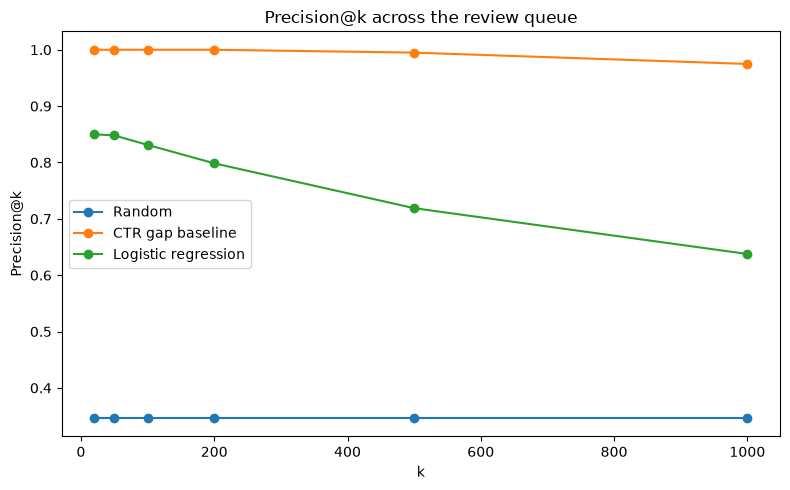

content_hash_id,total_clicks,total_impressions,weighted_avg_position,position_tier,search_volume,competition_level,ctr,expected_ctr,ctr_gap,predicted_high_gap,is_high_gap_mean,times_in_test,is_high_gap,reason_code,action
content_ec882c9a213fcfac,0.000000,232.000000,87.396552,page_3_plus,210,HIGH,0.000%,0.132%,0.001315,96.112%,100.00%,10,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.
content_fbf06c436d9d17b9,0.000000,265.000000,96.041509,page_3_plus,0,LOW,0.000%,0.127%,0.001272,95.913%,100.00%,14,1,CTR_GAP_REVIEW,Review - majority high-gap with lower search demand.
content_6530fa9d297c46eb,1.000000,9302.000000,86.984627,page_3_plus,0,LOW,0.011%,0.142%,0.001309,95.194%,0.00%,16,0,MODEL_SCORE_ONLY_NOT_HIGH_GAP,"Verify first - model ranked it high, but most evaluation labels did not call it high-gap."
content_fd499895590565e9,1.000000,251.000000,84.633466,page_3_plus,10,LOW,0.398%,0.132%,-0.002669,94.614%,0.00%,10,0,MODEL_SCORE_ONLY_NOT_HIGH_GAP,"Verify first - model ranked it high, but most evaluation labels did not call it high-gap."
content_c8d483384985811d,0.000000,336.000000,91.511905,page_3_plus,110,HIGH,0.000%,0.139%,0.001390,94.594%,100.00%,8,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.
content_188a66dd1177723c,0.000000,331.000000,85.785498,page_3_plus,0,LOW,0.000%,0.132%,0.001315,93.997%,100.00%,10,1,CTR_GAP_REVIEW,Review - majority high-gap with lower search demand.
content_2738cd6cfaeee57f,1.000000,623.000000,86.868379,page_3_plus,480,MEDIUM,0.161%,0.139%,-0.000216,93.987%,0.00%,8,0,MODEL_SCORE_ONLY_NOT_HIGH_GAP,"Verify first - model ranked it high, but most evaluation labels did not call it high-gap."
content_b813d79e8d1e865d,0.000000,225.000000,83.106667,page_3_plus,3600,HIGH,0.000%,0.139%,0.001394,93.838%,100.00%,18,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.
content_3912525ee96ac76e,0.000000,323.000000,87.492260,page_3_plus,210,MEDIUM,0.000%,0.139%,0.001390,93.817%,100.00%,8,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.
content_e76b204ac09f2b72,0.000000,208.000000,83.701923,page_3_plus,880,LOW,0.000%,0.138%,0.001383,93.735%,100.00%,6,1,HIGH_PRIORITY_CTR_GAP,Review first - majority high-gap with higher search demand.


In [24]:
from IPython.display import display
import matplotlib.pyplot as plt

os.makedirs("../outputs", exist_ok=True)

#artifact 1: data coverage
con.sql("""SELECT COUNT(*) AS total_rows, COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) AS available_rows,
           CONCAT(ROUND(100 * COUNT(*) FILTER (WHERE gsc_data_available IS TRUE) / COUNT(*), 2), '%') AS pct_available
           FROM fact_content_daily_performance_table""").show()


#artifact 2: the mean precision numbers from the final 50-seed validation
paper_results = summary_df[["k", "random_mean", "baseline_mean", "model_mean"]].copy()

display(paper_results.style.hide(axis="index").format({
    "random_mean": "{:.2%}",
    "baseline_mean": "{:.2%}",
    "model_mean": "{:.2%}"
}))


#artifact 3: a simple chart using the exact same numbers
plt.figure(figsize=(8,5))

plt.plot(paper_results["k"], paper_results["random_mean"], marker="o", label="Random")
plt.plot(paper_results["k"], paper_results["baseline_mean"], marker="o", label="CTR gap baseline")
plt.plot(paper_results["k"], paper_results["model_mean"], marker="o", label="Logistic regression")

plt.xlabel("k")
plt.ylabel("Precision@k")
plt.title("Precision@k across the review queue")
plt.legend()
plt.tight_layout()

plt.savefig("../outputs/capstone_precision_at_k.png", dpi=160, bbox_inches="tight")
plt.show()


#artifact 4: the review queue that was already built in section 6
display(final_queue[columns].head(20).style.hide(axis="index").format({
    "ctr": "{:.3%}",
    "expected_ctr": "{:.3%}",
    "ctr_gap": "{:.6f}",
    "predicted_high_gap": "{:.3%}",
    "is_high_gap_mean": "{:.2%}"
}).set_properties(**{"text-align": "center"}))


#saving the two tables so the deployed paper can reuse them
paper_results.to_csv("../outputs/capstone_precision_summary.csv", index=False)
final_queue[columns].head(100).to_csv("../outputs/capstone_top100_review_queue.csv", index=False)


## 5-Minute Demo Outline

**1- The question:** Of published pages with Google Search Console data, which pages get lower CTR than expected for similar search positions, and which should the SEO team review first?

**2- The method:** I aggregated March 2026 data to one row per client-page pair, removed pages with fewer than 200 impressions, and built a logistic regression model using pre-click features such as search position, search volume, and competition level.

**3- The label and validation:** A page is called high-gap when its CTR gap is at or above the training-data 70th percentile for its own position tier. Clients are kept separate between train and test, and the final result is averaged across 50 grouped splits because some clients have many more pages than others.

**4- The result:** The model's mean Precision@20 is about 85%, compared with about 35% from random selection. Precision@20 ranged from 45% to 100% across the grouped splits, so I report the average and the range instead of one lucky seed.

**5- The recommendation:** The final output is a ranked review queue. The SEO team can start at the top, use the reason code for context, and manually decide whether the title, metadata, search-intent match, or content needs attention. The project is decision-support, not proof that changing a page will cause CTR to improve.


## Social Post

I finished a machine learning capstone using FlyRank's search-performance internship data to build a ranked queue of pages that may deserve CTR review.

I used a simple logistic regression model with pre-click features and evaluated it with repeated client-grouped train/test splits so the same client never appears on both sides of a split. Across 50 grouped holdouts, the model averaged about 85% Precision@20 compared with about 35% from random selection, although the score varied a lot depending on which clients were held out.

The final output is a decision-support queue for SEO review, not an automatic recommendation to change a page and not a causal claim that an edit will improve CTR.


## Employer-facing summary

I built a CTR-opportunity prioritization tool using March 2026 FlyRank internship warehouse data and a logistic regression model with pre-click features.

I used client-grouped validation and repeated the holdout 50 times because client sizes were very uneven; the model averaged about 85% Precision@20 versus about 35% random selection, while the wide split-to-split range was reported as a limitation.

The project demonstrates data aggregation, feature engineering, leakage checks, grouped validation, baseline comparison, and turning model scores into a ranked action queue for human review.


## Self-check

Before you submit, confirm each line honestly:

- [ x ] Every section above is filled — markdown thinking AND the code that backs it
- [ x ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ x ] No client names, URLs, or private queries anywhere
- [ x ] My claims use careful words: observed, measured, directional, decision-support
- [ x ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ x ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ x ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
